In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("train.csv")

In [3]:
new_df = df.sample(50000)

In [4]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
199080,199080,200804,94029,How do you stop German Shepherd/Husky puppies ...,How do I stop my puppy from chewing my shoes?,1
49898,49898,88748,88749,How do I root Micromax canvas 5?,What is the best way to root micromax canvas j...,0
147429,147429,98975,99694,What hotel in Dharamshala Hill-station would b...,What hotel in Lansdowne Hill-station would be ...,0
292501,292501,356693,222172,Is it safe to travel to Philippines now?,Is Philippines safe for travel?,1
272780,272780,19408,391107,Mathematical Puzzles: What is () + () + () = 3...,"What is the rule to the sequence 2, 5, 9, 13, ...",0


In [5]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [6]:
new_df.duplicated().sum()

0

Text Preprocessing

In [ ]:
import re
import string

CONTRACTIONS = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'t": " not",
    "'ve": " have",
    "'m": " am",
}


def preprocess_text(text, stem=False):
    """Clean raw text and prepare it for feature extraction.

    Steps:
    - lowercasing
    - normalize contractions
    - remove HTML tags, URLs, emails, mentions, and hashtags
    - remove punctuation, digits, and extra whitespace
    - optional stemming when nltk is available
    """
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()

    for old, new in CONTRACTIONS.items():
        text = text.replace(old, new)

    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[@#]\w+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    if stem:
        try:
            from nltk.stem import PorterStemmer
            stemmer = PorterStemmer()
            tokens = [stemmer.stem(token) for token in tokens]
        except Exception:
            pass

    return " ".join(tokens)


sample_text = "<p>How can I improve my coding skills? Visit https://example.com now! I can't wait :)</p>"
preprocess_text(sample_text)

'how can i improve my coding skills visit now i cannot wait'

In [9]:
new_df['question1']= new_df['question1'].apply(preprocess_text)
new_df['question2']= new_df['question2'].apply(preprocess_text)

In [10]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
199080,199080,200804,94029,how do you stop german shepherdhusky puppies f...,how do i stop my puppy from chewing my shoes,1
49898,49898,88748,88749,how do i root micromax canvas,what is the best way to root micromax canvas j...,0
147429,147429,98975,99694,what hotel in dharamshala hillstation would be...,what hotel in lansdowne hillstation would be s...,0
292501,292501,356693,222172,is it safe to travel to philippines now,is philippines safe for travel,1
272780,272780,19408,391107,mathematical puzzles what is using,what is the rule to the sequence,0


Feature-Engineering

In [11]:
new_df['q1_length']= new_df['question1'].str.len()
new_df['q2_length']= new_df['question2'].str.len()

In [12]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length
199080,199080,200804,94029,how do you stop german shepherdhusky puppies f...,how do i stop my puppy from chewing my shoes,1,67,44
49898,49898,88748,88749,how do i root micromax canvas,what is the best way to root micromax canvas j...,0,29,50
147429,147429,98975,99694,what hotel in dharamshala hillstation would be...,what hotel in lansdowne hillstation would be s...,0,135,133
292501,292501,356693,222172,is it safe to travel to philippines now,is philippines safe for travel,1,39,30
272780,272780,19408,391107,mathematical puzzles what is using,what is the rule to the sequence,0,34,32


In [19]:
new_df['q1_num_words']= new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words']= new_df['question2'].apply(lambda row: len(row.split(" ")))

In [20]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words
199080,199080,200804,94029,how do you stop german shepherdhusky puppies f...,how do i stop my puppy from chewing my shoes,1,67,44,11,10
49898,49898,88748,88749,how do i root micromax canvas,what is the best way to root micromax canvas j...,0,29,50,6,10
147429,147429,98975,99694,what hotel in dharamshala hillstation would be...,what hotel in lansdowne hillstation would be s...,0,135,133,21,21
292501,292501,356693,222172,is it safe to travel to philippines now,is philippines safe for travel,1,39,30,8,5
272780,272780,19408,391107,mathematical puzzles what is using,what is the rule to the sequence,0,34,32,5,7


In [39]:
new_df['common_words'] = new_df.apply(
    lambda row: len(set(row['question1'].lower().split())
                    & set(row['question2'].lower().split())),
    axis=1
)

In [41]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,common_words
199080,199080,200804,94029,how do you stop german shepherdhusky puppies f...,how do i stop my puppy from chewing my shoes,1,67,44,11,10,4
49898,49898,88748,88749,how do i root micromax canvas,what is the best way to root micromax canvas j...,0,29,50,6,10,3
147429,147429,98975,99694,what hotel in dharamshala hillstation would be...,what hotel in lansdowne hillstation would be s...,0,135,133,21,21,18
292501,292501,356693,222172,is it safe to travel to philippines now,is philippines safe for travel,1,39,30,8,5,4
272780,272780,19408,391107,mathematical puzzles what is using,what is the rule to the sequence,0,34,32,5,7,2


In [44]:
new_df['total_words'] = new_df.apply(lambda row: len(set(row['question1'].lower().split())) + len(set(row['question2'].lower().split())), axis=1)

In [45]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,common_words,total_words
199080,199080,200804,94029,how do you stop german shepherdhusky puppies f...,how do i stop my puppy from chewing my shoes,1,67,44,11,10,4,20
49898,49898,88748,88749,how do i root micromax canvas,what is the best way to root micromax canvas j...,0,29,50,6,10,3,16
147429,147429,98975,99694,what hotel in dharamshala hillstation would be...,what hotel in lansdowne hillstation would be s...,0,135,133,21,21,18,38
292501,292501,356693,222172,is it safe to travel to philippines now,is philippines safe for travel,1,39,30,8,5,4,12
272780,272780,19408,391107,mathematical puzzles what is using,what is the rule to the sequence,0,34,32,5,7,2,11


In [46]:
new_df['word_share']= np.round(new_df['common_words']/new_df['total_words'], 2)

In [47]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,common_words,total_words,word_share
199080,199080,200804,94029,how do you stop german shepherdhusky puppies f...,how do i stop my puppy from chewing my shoes,1,67,44,11,10,4,20,0.20
49898,49898,88748,88749,how do i root micromax canvas,what is the best way to root micromax canvas j...,0,29,50,6,10,3,16,0.19
147429,147429,98975,99694,what hotel in dharamshala hillstation would be...,what hotel in lansdowne hillstation would be s...,0,135,133,21,21,18,38,0.47
292501,292501,356693,222172,is it safe to travel to philippines now,is philippines safe for travel,1,39,30,8,5,4,12,0.33
272780,272780,19408,391107,mathematical puzzles what is using,what is the rule to the sequence,0,34,32,5,7,2,11,0.18


In [48]:
# Advanced Features
from nltk.corpus import stopwords


def fetch_token_features(row):

    q1 = row['question1']
    q2 = row['question2']

    SAFE_DIV = 0.0001

    STOP_WORDS = stopwords.words("english")

    token_features = [0.0]*8

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    # Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))

    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    token_features[0] = common_word_count / \
        (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / \
        (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / \
        (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / \
        (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / \
        (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / \
        (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

In [49]:
token_features = new_df.apply(fetch_token_features, axis=1)

new_df["cwc_min"] = list(map(lambda x: x[0], token_features))
new_df["cwc_max"] = list(map(lambda x: x[1], token_features))
new_df["csc_min"] = list(map(lambda x: x[2], token_features))
new_df["csc_max"] = list(map(lambda x: x[3], token_features))
new_df["ctc_min"] = list(map(lambda x: x[4], token_features))
new_df["ctc_max"] = list(map(lambda x: x[5], token_features))
new_df["last_word_eq"] = list(map(lambda x: x[6], token_features))
new_df["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [55]:
import distance


def fetch_length_features(row):

    q1 = row['question1']
    q2 = row['question2']

    length_features = [0.0]*3

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    # Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2

    strs = list(distance.lcsubstrings(q1, q2))
    # Handle case when no common substrings exist
    if strs:
        length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    else:
        length_features[2] = 0.0

    return length_features

In [56]:
length_features = new_df.apply(fetch_length_features, axis=1)

new_df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
new_df['mean_len'] = list(map(lambda x: x[1], length_features))
new_df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [59]:
# Fuzzy Features
from fuzzywuzzy import fuzz


def fetch_fuzzy_features(row):

    q1 = row['question1']
    q2 = row['question2']

    fuzzy_features = [0.0]*4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

c:\Users\Acer\anaconda3\envs\py310\lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [60]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
new_df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
new_df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
new_df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
new_df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

In [61]:
print(new_df.shape)
new_df.head()

(50000, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
199080,199080,200804,94029,how do you stop german shepherdhusky puppies f...,how do i stop my puppy from chewing my shoes,1,67,44,11,10,...,0.363633,0.0,1.0,1.0,10.5,0.155556,59,52,54,59
49898,49898,88748,88749,how do i root micromax canvas,what is the best way to root micromax canvas j...,0,29,50,6,10,...,0.299997,0.0,0.0,4.0,8.0,0.700000,61,76,58,82
147429,147429,98975,99694,what hotel in dharamshala hillstation would be...,what hotel in lansdowne hillstation would be s...,0,135,133,21,21,...,0.857139,1.0,1.0,0.0,21.0,0.820896,94,93,92,96
292501,292501,356693,222172,is it safe to travel to philippines now,is philippines safe for travel,1,39,30,8,5,...,0.499994,0.0,1.0,3.0,6.5,0.419355,46,58,75,93
272780,272780,19408,391107,mathematical puzzles what is using,what is the rule to the sequence,0,34,32,5,7,...,0.285710,0.0,0.0,2.0,6.0,0.242424,33,49,39,40


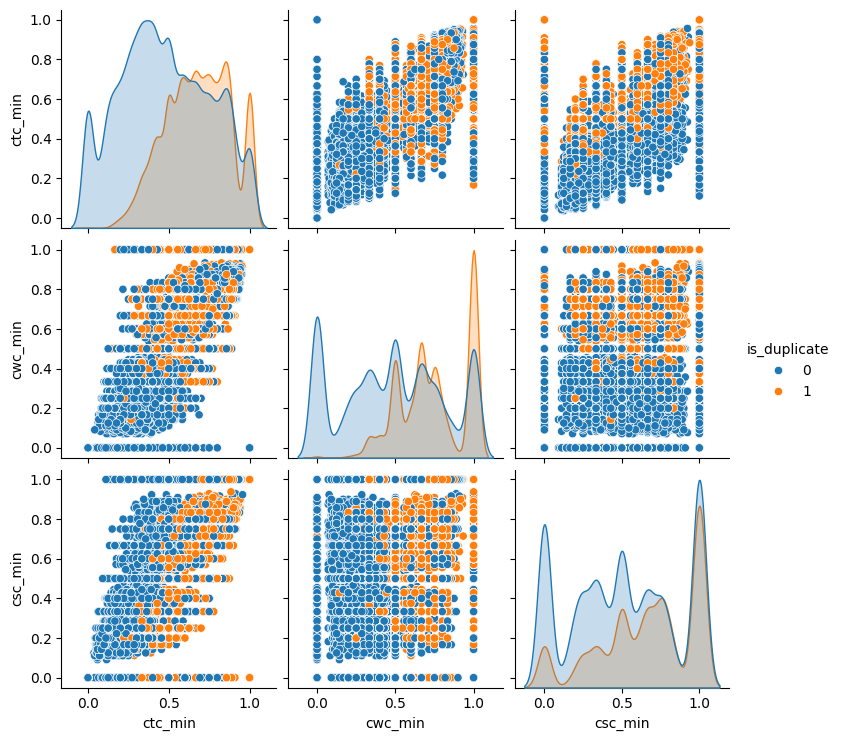

In [62]:
sns.pairplot(new_df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']], hue='is_duplicate')

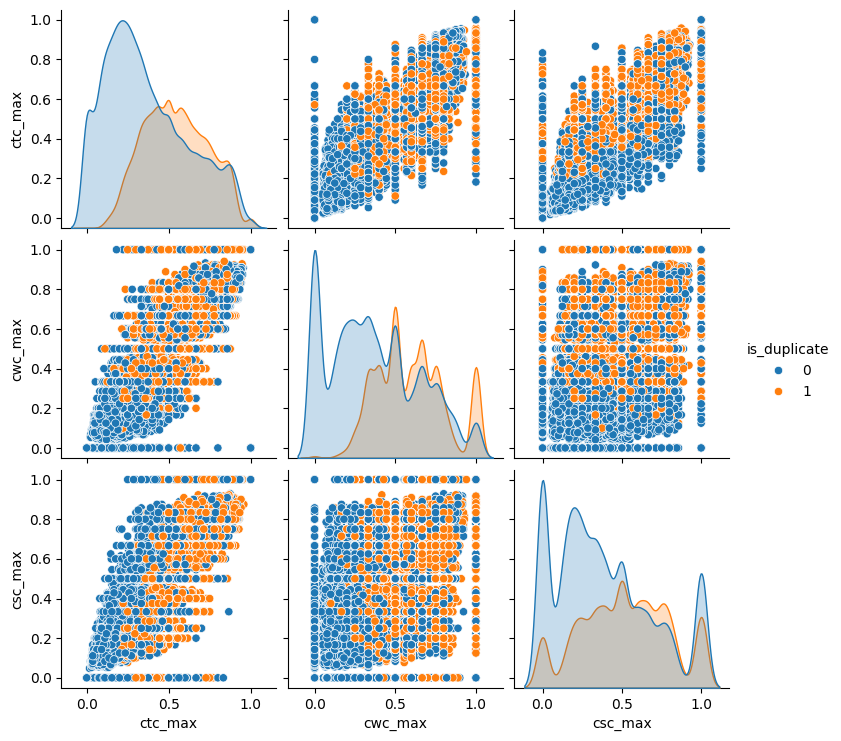

In [63]:
sns.pairplot(new_df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']], hue='is_duplicate')

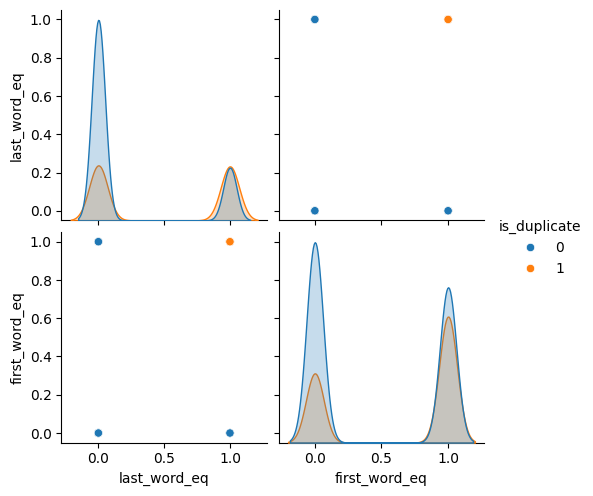

In [64]:
sns.pairplot(new_df[['last_word_eq', 'first_word_eq', 'is_duplicate']], hue='is_duplicate')

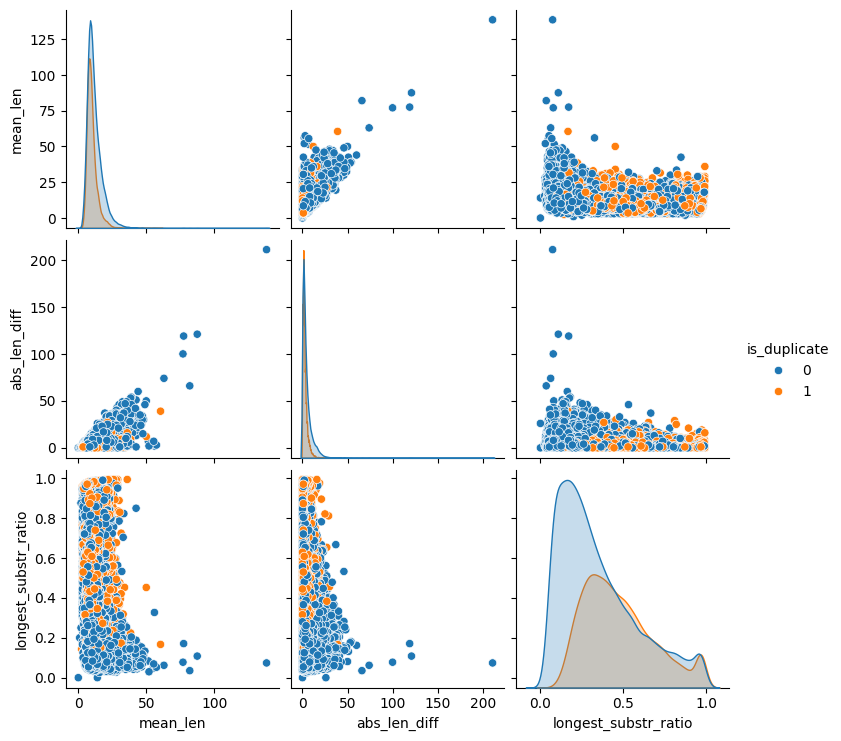

In [65]:
sns.pairplot(new_df[['mean_len', 'abs_len_diff', 'longest_substr_ratio', 'is_duplicate']],hue='is_duplicate')

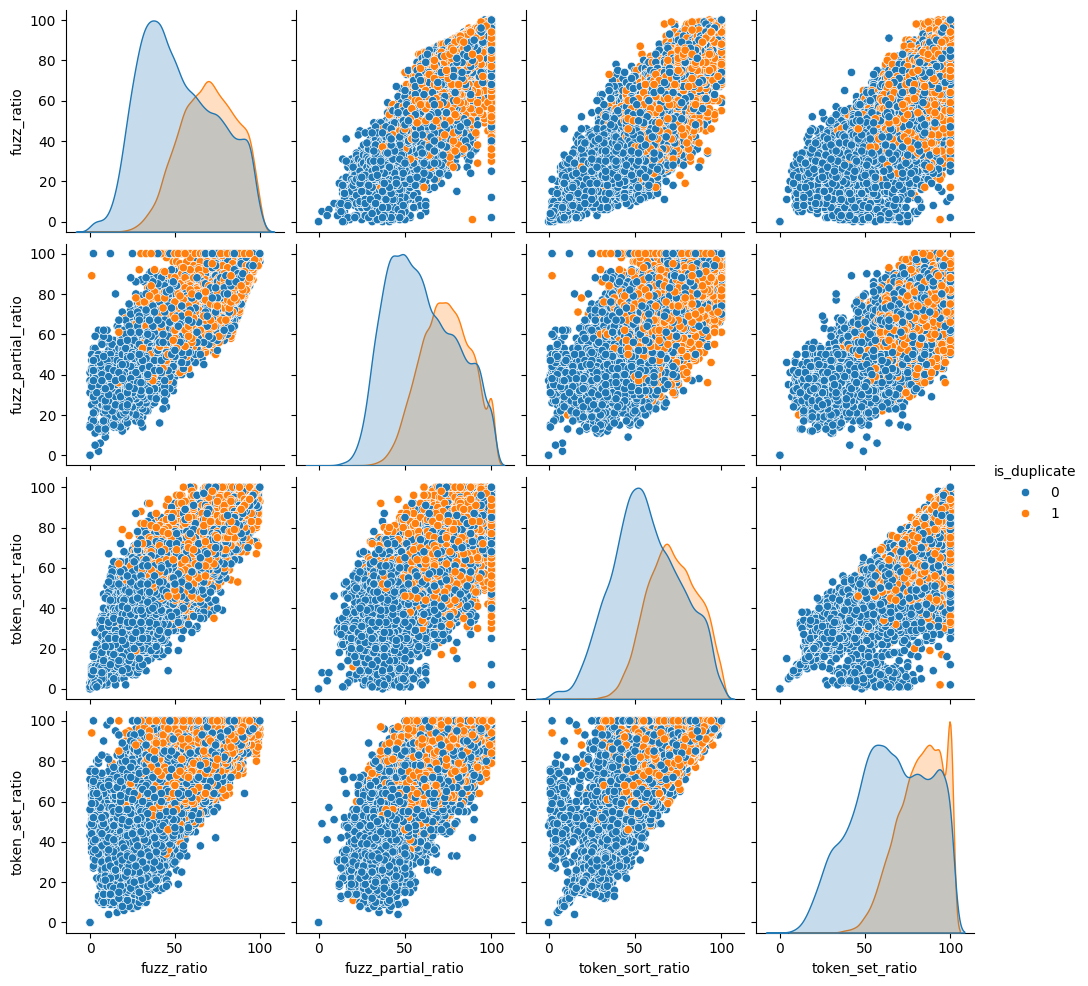

In [66]:
sns.pairplot(new_df[['fuzz_ratio', 'fuzz_partial_ratio', 'token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')

In [67]:
ques_df = new_df[['question1', 'question2']]
ques_df.head()

,question1,question2
199080,how do you stop german shepherdhusky puppies f...,how do i stop my puppy from chewing my shoes
49898,how do i root micromax canvas,what is the best way to root micromax canvas j...
147429,what hotel in dharamshala hillstation would be...,what hotel in lansdowne hillstation would be s...
292501,is it safe to travel to philippines now,is philippines safe for travel
272780,mathematical puzzles what is using,what is the rule to the sequence


In [68]:

final_df = new_df.drop(
    columns=['id', 'qid1', 'qid2', 'question1', 'question2'])
print(final_df.shape)
final_df.head()

(50000, 23)


,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,common_words,total_words,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
199080,1,67,44,11,10,4,20,0.20,0.249994,0.166664,...,0.363633,0.0,1.0,1.0,10.5,0.155556,59,52,54,59
49898,0,29,50,6,10,3,16,0.19,0.999967,0.499992,...,0.299997,0.0,0.0,4.0,8.0,0.700000,61,76,58,82
147429,0,135,133,21,21,18,38,0.47,0.916659,0.916659,...,0.857139,1.0,1.0,0.0,21.0,0.820896,94,93,92,96
292501,1,39,30,8,5,4,12,0.33,0.999967,0.999967,...,0.499994,0.0,1.0,3.0,6.5,0.419355,46,58,75,93
272780,0,34,32,5,7,2,11,0.18,0.000000,0.000000,...,0.285710,0.0,0.0,2.0,6.0,0.242424,33,49,39,40


In [69]:
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(), 2)

In [70]:
temp_df1 = pd.DataFrame(q1_arr, index=ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index=ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(50000, 6000)

In [71]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(50000, 6023)


,is_duplicate,q1_length,q2_length,q1_num_words,q2_num_words,common_words,total_words,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
199080,1,67,44,11,10,4,20,0.20,0.249994,0.166664,...,0,0,0,0,0,0,0,0,0,0
49898,0,29,50,6,10,3,16,0.19,0.999967,0.499992,...,0,0,0,0,0,0,0,0,0,0
147429,0,135,133,21,21,18,38,0.47,0.916659,0.916659,...,0,0,0,0,0,0,0,0,0,0
292501,1,39,30,8,5,4,12,0.33,0.999967,0.999967,...,0,0,0,0,0,0,0,0,0,0
272780,0,34,32,5,7,2,11,0.18,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0


In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.7901

In [74]:
import pickle

pickle.dump(rf, open('model.pkl','wb'))